In [3]:
import sys
import importlib
import pandas as pd
import numpy as np
from pathlib import Path
from utils.model_classes import XGBModel

PROJECT_ROOT = Path().resolve().parent.parent.parent.parent
print(f"Project root: {PROJECT_ROOT}")
PATH_DATA = PROJECT_ROOT / 'data' / 'exploded_splits'
print(f"Data: {PATH_DATA}")

TEXTUAL_EMBEDDING_PATH = PROJECT_ROOT / 'data' / 'textual_features'
text_emb_128 = TEXTUAL_EMBEDDING_PATH / 'textual_embeddings_128.parquet'

RANDOM_STATE = 42

import torch
# Detect device: 'cuda' if available, else 'cpu'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# for parallelization
N_JOBS = -1 if torch.cuda.is_available() else 1

Project root: C:\Users\ivan.bernacchia\OneDrive - TINEXT SA\Documents\_Alessia\M-P6203E-DataProjects-Hackaton3_P1
Data: C:\Users\ivan.bernacchia\OneDrive - TINEXT SA\Documents\_Alessia\M-P6203E-DataProjects-Hackaton3_P1\data\exploded_splits
Using device: cpu


# XGB Model - on textual embeddings
By leveraging textual embeddings (128-dimensional vectors representing paper content), we treat the problem as a supervised learning task.

To ensure code quality and reusability, we implement a custom class hierarchy:

- `BaseModel`: An abstract class that defines the blueprint for all models. It enforces the implementation of `preprocess()` method and provides standardized `train_pipeline` and `test_pipeline` methods.

- `XGBModel`: The concrete implementation of the baseline. It encapsulates the feature engineering logic (dropping non-feature columns) and stateful preprocessing (storing a `StandardScaler` to ensure the test set is scaled using training statistics).


## 1. Import dataframe with embeddings

In [3]:
df = pd.read_parquet(text_emb_128)
display(df.head())
print(df.shape)

,split,article_id,ref_id,is_reference_valid,article_emb_000,article_emb_001,article_emb_002,article_emb_003,article_emb_004,article_emb_005,...,ref_emb_118,ref_emb_119,ref_emb_120,ref_emb_121,ref_emb_122,ref_emb_123,ref_emb_124,ref_emb_125,ref_emb_126,ref_emb_127
0,train,53e99f0ab7602d97027d6a89,53e99ff0b7602d97028d14d3,1,0.256074,-0.008567,0.029547,0.027875,-0.039097,0.061652,...,0.064212,0.001819,0.028266,0.074405,-0.012687,-0.012413,-0.018658,0.019843,-0.018603,-0.062412
1,train,53e9bd81b7602d9704a24d06,557f4d4f6fee0fe990cb035f,1,0.177240,0.009653,-0.006376,0.139197,0.036759,0.024399,...,-0.002640,0.002758,-0.021711,0.000173,0.036031,0.010025,-0.032560,-0.004902,0.012356,-0.037394
2,train,539087fe20f70186a0d75db6,539087ae20f70186a0d4cf5a,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,-0.025537,0.005557,0.027970,0.036103,0.017138,-0.040106,0.029802,-0.020301,-0.001983,-0.039484
3,train,539087fe20f70186a0d75db6,5390878e20f70186a0d3a260,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,0.022904,0.030194,0.019120,-0.022178,-0.037727,0.054251,-0.055143,0.056518,-0.040537,-0.131712
4,train,539087fe20f70186a0d75db6,539087cb20f70186a0d58fe1,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,-0.028705,-0.019178,-0.046387,-0.040602,0.018601,0.018564,0.042588,0.064933,0.001457,0.016216


(2950135, 260)


In [4]:
# splitting
split_series = df["split"].astype(str).str.lower()
df_train = df[split_series == "train"].copy()
df_val = df[split_series.isin(["validation", "val"])].copy()
df_test = df[split_series == "test"].copy()

print("\nSplit sizes:", {"train": len(df_train), "test": len(df_test), "val": len(df_val)})


Split sizes: {'train': 2162513, 'test': 396380, 'val': 391242}


## 2. Baseline Model

[XGB_baseline] Preprocessing data...
Label distribution:
is_reference_valid
1    0.5037
0    0.4963
Name: proportion, dtype: float64
[XGB_baseline] Starting training...


c:\Users\ivan.bernacchia\AppData\Local\anaconda3\envs\hack_03\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:59:33] WARNING: D:\bld\xgboost-split_1772124962567\work\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      4963
           1     1.0000    1.0000    1.0000      5037

    accuracy                         1.0000     10000
   macro avg     1.0000    1.0000    1.0000     10000
weighted avg     1.0000    1.0000    1.0000     10000



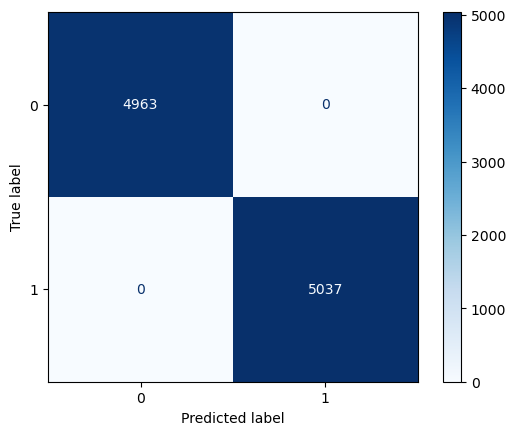

In [ ]:
XGB_baseline = XGBModel('XGB_baseline', tree_method="hist")
XGB_baseline.train_pipeline(df_train, )

[XGB_baseline] Preprocessing data...
Label distribution:
is_reference_valid
0    0.5121
1    0.4879
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.7332    0.7391    0.7362      5121
           1     0.7239    0.7178    0.7208      4879

    accuracy                         0.7287     10000
   macro avg     0.7285    0.7284    0.7285     10000
weighted avg     0.7287    0.7287    0.7287     10000



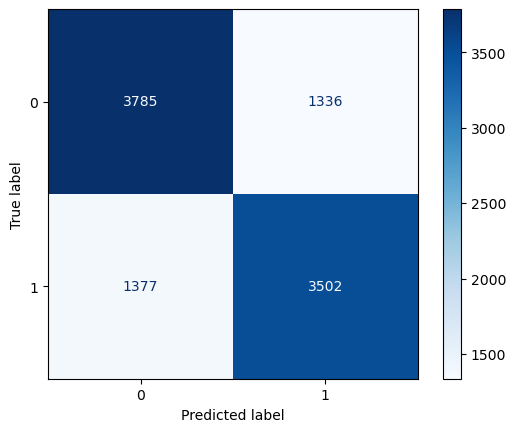

In [17]:
XGB_baseline.test_pipeline(df_test.sample(10000))

## 3. Hypertuning
Given the high dimensionality of features and the complexity of the `XGBoost` algorithm, performing an exhaustive search of all parameter combinations is computationally prohibitive. To optimize performance, we utilize `RandomizedSearchCV` instead of `GridSearchCV`.

While `GridSearchCV` evaluates every possible combination in a fixed grid, `RandomizedSearchCV` samples a fixed number of parameter settings from specified distributions. This approach allows us to explore a wider range of hyperparameters (like learning rate, tree depth, and regularization) more efficiently, often finding an optimal solution in a fraction of the time.

For the cross-validation strategy, we use a 2-fold approach (cv=2) on a controlled subset. This ensures that the model's generalization is tested across different data partitions while keeping the memory footprint low, which is critical when working with GPU-accelerated training and large embedding arrays on Windows systems.

In [ ]:
# Valid hyperparameters for XGBClassifier
param_dist = {
    "n_estimators": [100, 200, 500],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [1, 5, 10],
    "scale_pos_weight": [1, 2, 5],
}

In [ ]:
# tuning
XGB_textual_128 = XGBModel("XGB_textual_128", tree_method="hist")
XGB_textual_128.hypertune_pipeline(df_train, df_val, param_dist, 
                            n_iter=20,
                            cv=2,
                            scoring="f1",
                            random_state=RANDOM_STATE,
                            n_jobs=N_JOBS,
                            pre_dispatch=N_JOBS,
                            error_score="raise",
                            verbose=2,
                        )

[XGB] Preprocessing data...
Label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64
[XGB] Preprocessing data...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
Fitting 2 folds for each of 20 candidates, totalling 40 fits


c:\Users\ivan.bernacchia\AppData\Local\anaconda3\envs\hack_03\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:13:15] WARNING: D:\bld\xgboost-split_1772124962567\work\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=10, n_estimators=100, reg_lambda=5, scale_pos_weight=5, subsample=1.0; total time=  49.8s


c:\Users\ivan.bernacchia\AppData\Local\anaconda3\envs\hack_03\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:14:05] WARNING: D:\bld\xgboost-split_1772124962567\work\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=10, n_estimators=100, reg_lambda=5, scale_pos_weight=5, subsample=1.0; total time=  48.4s


...

c:\Users\ivan.bernacchia\AppData\Local\anaconda3\envs\hack_03\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:15:47] WARNING: D:\bld\xgboost-split_1772124962567\work\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, n_estimators=500, reg_lambda=5, scale_pos_weight=2, subsample=1.0; total time=  29.4s


c:\Users\ivan.bernacchia\AppData\Local\anaconda3\envs\hack_03\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:16:16] WARNING: D:\bld\xgboost-split_1772124962567\work\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=10, n_estimators=500, reg_lambda=10, scale_pos_weight=5, subsample=1.0; total time= 2.9min


c:\Users\ivan.bernacchia\AppData\Local\anaconda3\envs\hack_03\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:19:09] WARNING: D:\bld\xgboost-split_1772124962567\work\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


## 4. Final model with best params
Once the optimal hyperparameters (number of neighbors, weight function, and distance metric) are found, the model is retrained on the full training set.

Performance is assessed using:
- Weighted F1-Score: To account for any slight imbalances in class distribution.
- Confusion Matrix: To visualize Type I and Type II errors.
- Classification Report: Providing precision, recall, and accuracy at a granular level.

In [ ]:
# final training creating model with best params
XGB_textual_128.test_pipeline(df_test)


Best parameters found:
{'metric': 'euclidean', 'n_neighbors': 12, 'weights': 'uniform'}
[KNN_textual] Preprocessing data...
Label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64
[KNN_textual] Starting training...


## 5. Save the Model pretrained
Finally, the trained model and its associated metadata (parameters, data source name, and performance summary) are saved using a custom `save_model_artifact` utility, allowing for easy deployment or further testing.

In [ ]:
#TODO
XGB_textual_128.save_model()